In [5]:
import os
import yaml
import dotenv
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAI, GoogleGenerativeAIEmbeddings

In [6]:
env_path = r"D:\common_credentials\.env"
load_dotenv(dotenv_path=env_path)

True

In [7]:
with open("../config.yml", "r") as yml_file:
    yml_config= yaml.safe_load(yml_file)
    yml_file.close()
print(yml_config['GroqModels']["Inferencing_Models"]['text_models'])

['distil-whisper-large-v3-en', 'gemma2-9b-it', 'llama-3.3-70b-versatile', 'llama-3.1-8b-instant', 'whisper-large-v3-turbo', 'deepseek-r1-distill-llama-70b']


In [8]:
# llm= ChatGroq(model="qwen-2.5-32b")
# llm= ChatGroq(model="llama-3.1-8b-instant")
modelid= 'deepseek-r1-distill-llama-70b'
llm = ChatGroq(model=modelid)

In [9]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[add,multiply,divide]

# llm=ChatOpenAI(model="gpt-4o")

## to stop the parallel execution
llm_with_tools=llm.bind_tools(tools,parallel_tool_calls=False)

In [10]:
from langgraph.graph import MessagesState

In [11]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict


class MessagesState(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [12]:
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs")


def assistant(state:MessagesState):
    ## LLM
    return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

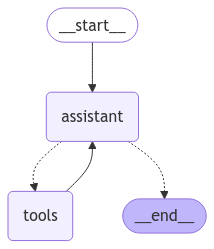

In [13]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

builder=StateGraph(MessagesState)

## Define the node
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

## Define the edges

builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools","assistant")

react_graph=builder.compile()

# Show
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [14]:
messages = [HumanMessage(content="add 2 + 2 and multiply it with 4")]
messages = react_graph.invoke({"messages": messages})

In [15]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

add 2 + 2 and multiply it with 4
================================== Ai Message ==================================
Tool Calls:
  add (call_garj)
 Call ID: call_garj
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
================================== Ai Message ==================================
Tool Calls:
  add (call_qfrf)
 Call ID: call_qfrf
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
================================== Ai Message ==================================

To solve "add 2 + 2 and multiply it with 4," we'll break it down into two steps:

1. **Addition:**  
   \( 2 + 2 = 4 \)

2. **Multiplication:**  
   \( 4 \times 4 = 16 \)

**Final Answer:**  
\boxed{16}


# MEmeory In Agents Using MemorySaver

![image.png](attachment:image.png)

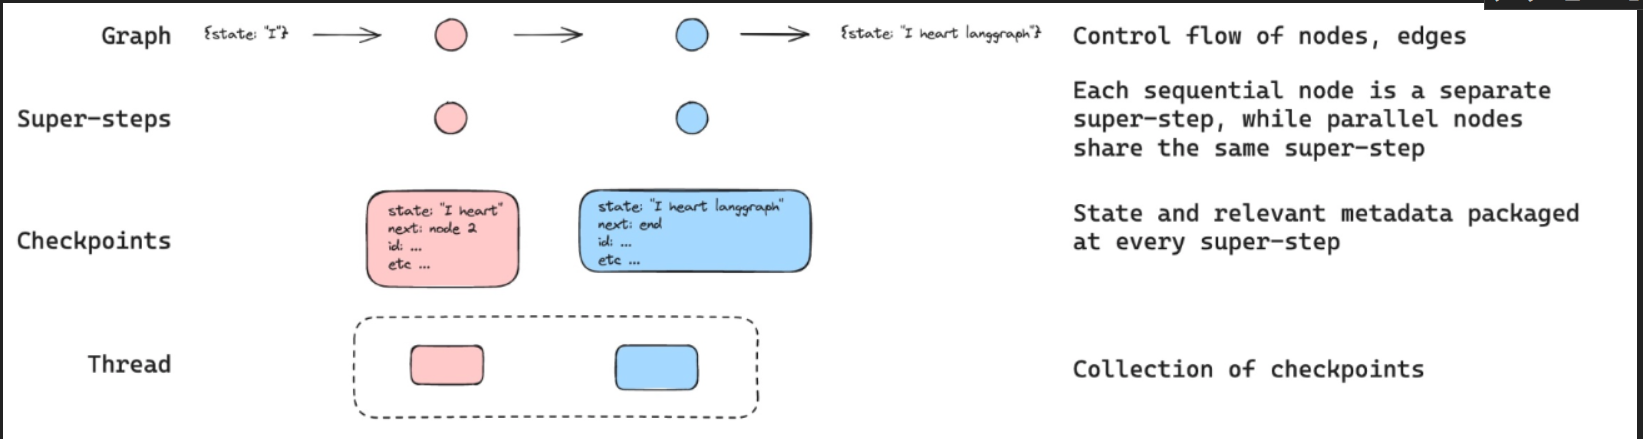

In [16]:
from langgraph.checkpoint.memory import MemorySaver

In [17]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

react_graph=builder.compile(checkpointer=memory)

In [18]:
config={"configurable":{"thread_id":"1"}}
# Specify an input
messages = [HumanMessage(content="Add 3 and 4.")]

# Run
messages = react_graph.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()


================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_yddk)
 Call ID: call_yddk
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  add (call_9y1x)
 Call ID: call_9y1x
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

<tool_call>{"id":"call_9y1x","name":"add","arguments":{"a":3,"b":4}}<｜tool▁calls▁end｜>


In [19]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_yddk)
 Call ID: call_yddk
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  add (call_9y1x)
 Call ID: call_9y1x
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

<tool_call>{"id":"call_9y1x","name":"add","arguments":{"a":3,"b":4}}<｜tool▁calls▁end｜>
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (call_hf9h)
 Call ID: call_h